# Raw .bin → CIR Exploration

Reads binary measurement frames, parses IQ / GPS fields, and applies the LFM matched-filter sliding correlation to produce the raw (uncalibrated) CIR.

**Reference:** `src/io/bin_read.py`

## 1  Imports & project root

In [ ]:
import sys, math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import contextily as ctx
from pyproj import Transformer

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io.bin_read import (
    read_bin_to_cir,
    _load_frames,
    _parse_iq,
    _parse_gps,
    _sliding_correlate,
    _DEVICE,
    FRAME_LEN, U, FS_HZ, BW_HZ,
)
from src.paths import RAW_MEA_DIR, RAW_CALI_DIR

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

print(f"Project root : {PROJECT_ROOT}")
print(f"FRAME_LEN={FRAME_LEN}, U={U}, FS_HZ={FS_HZ/1e6:.0f} MHz, BW={BW_HZ/1e6:.0f} MHz")
print(f"Compute device: {_DEVICE}" + (" ✓ GPU" if _DEVICE.type == "cuda" else " (CPU fallback)"))


Project root : /home/guo/桌面/project/chan_meas
FRAME_LEN=4132, U=1024, FS_HZ=100 MHz, BW=50 MHz
Compute device: cuda ✓ GPU


## 2  Select data file

In [2]:
# ── Pick one file to explore ─────────────────────────────────────────────────
# Change this path to the actual .bin you want to inspect
BIN_PATH = RAW_MEA_DIR  # or RAW_CALI_DIR, or a specific Path("...").bin

MAX_FRAMES = None  # limit for fast iteration; set None for all frames

print(f"Data path  : {BIN_PATH}")
print(f"Max frames : {MAX_FRAMES}")

Data path  : /mnt/win_data/data_mea/data_save/Mea_data
Max frames : None


## 3  Load raw frames

In [3]:
# Available: East_campus_3200M_2_rolls.bin, East_West_campus_1400M.bin,
#            shaolong_1400M.bin, shaolong_3200M.bin, Wset_campus_3200M.bin
BIN_PATH = RAW_MEA_DIR / "0513_mea_data" / "East_campus_3200M_2_rolls.bin"
frames = _load_frames(BIN_PATH, max_frames=MAX_FRAMES)
n_frames = frames.shape[0]

print(f"frames.shape = {frames.shape}  (n_frames × FRAME_LEN)")
print(f"Total bytes loaded: {frames.nbytes / 1e6:.2f} MB")

frames.shape = (74917, 4132)  (n_frames × FRAME_LEN)
Total bytes loaded: 309.56 MB


## 4  Parse GPS fields

In [4]:
gps = _parse_gps(frames)

for key, val in gps.items():
    print(f"  {key:8s}: min={val.min():.6g}  max={val.max():.6g}  (first 5: {val[:5]})")

  lat     : min=31.9375  max=31.943  (first 5: [31.93937667 31.93937667 31.93937667 31.93937667 31.93937667])
  lon     : min=118.789  max=118.793  (first 5: [118.79040183 118.79040183 118.79040183 118.79040183 118.79040183])
  alt     : min=9.6  max=17.3  (first 5: [14.6 14.6 14.6 14.6 14.6])
  hour    : min=2  max=2  (first 5: [2 2 2 2 2])
  minute  : min=12  max=19  (first 5: [12 12 12 12 12])
  second  : min=0  max=59  (first 5: [50 50 50 50 50])


Text(0.5, 1.0, 'GPS Trajectory')

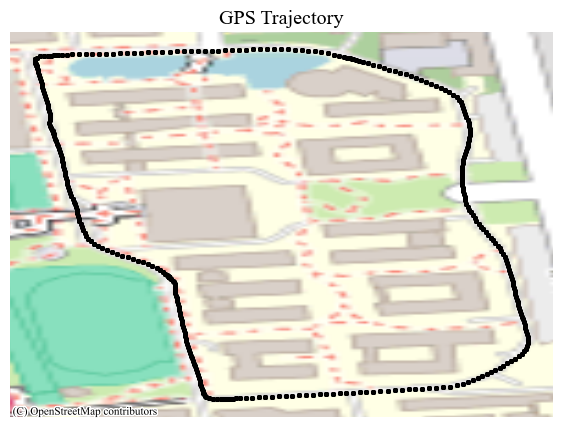

In [5]:
import contextily as ctx
from pyproj import Transformer

fig, ax0 = plt.subplots(1, 1, figsize=(7, 5))

_tr = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
_x, _y = _tr.transform(gps['lon'], gps['lat'])

# 每 20 帧取一点，视觉无损
step = 20
ax0.scatter(_x[::step], _y[::step], s=6, color='k', zorder=5)

# zoom 固定，tiles 首次下载后本地缓存
ctx.add_basemap(ax0, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15)
ax0.set_axis_off()
ax0.set_title('GPS Trajectory')


## 5  Parse IQ and inspect raw signal

iq.shape = (74917, 1024)  (n_frames × U), dtype=complex64


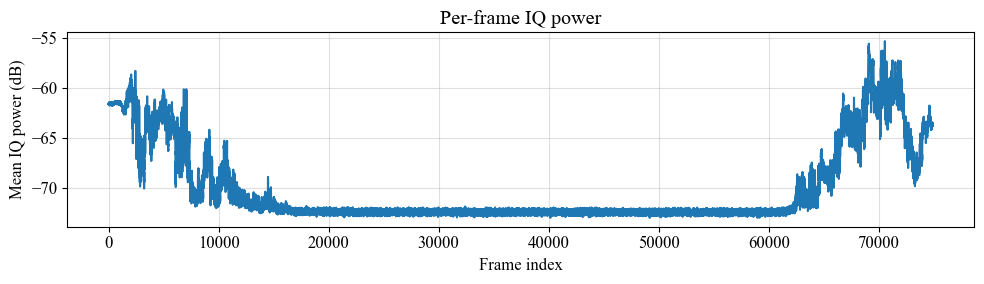

In [7]:
iq = _parse_iq(frames)
print(f"iq.shape = {iq.shape}  (n_frames × U), dtype={iq.dtype}")

# Per-frame power — computed on GPU
_iq_t = torch.from_numpy(iq).to(_DEVICE)
power_per_frame_db = 10 * np.log10(                                                                                                                                     
(np.abs(iq) ** 2).mean(axis=1) + 1e-30                                                                                                                              
) 

plt.figure(figsize=(10, 3))
plt.plot(power_per_frame_db)
plt.xlabel('Frame index')
plt.ylabel('Mean IQ power (dB)')
plt.title('Per-frame IQ power')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


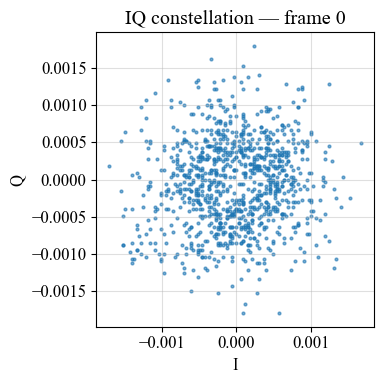

In [8]:
# IQ constellation of one frame
frame_idx = 0
plt.figure(figsize=(4, 4))
plt.scatter(iq[frame_idx].real, iq[frame_idx].imag, s=4, alpha=0.6)
plt.xlabel('I')
plt.ylabel('Q')
plt.title(f'IQ constellation — frame {frame_idx}')
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6  Matched-filter correlation → raw CIR

In [9]:
cir_raw = _sliding_correlate(iq)   # modifies iq in-place (DC removal)
print(f"cir_raw.shape = {cir_raw.shape}  (n_frames × U), dtype={cir_raw.dtype}")

delay_axis_ns = np.arange(U) / BW_HZ * 1e9  # delay bins → nanoseconds

cir_raw.shape = (74917, 1024)  (n_frames × U), dtype=complex64


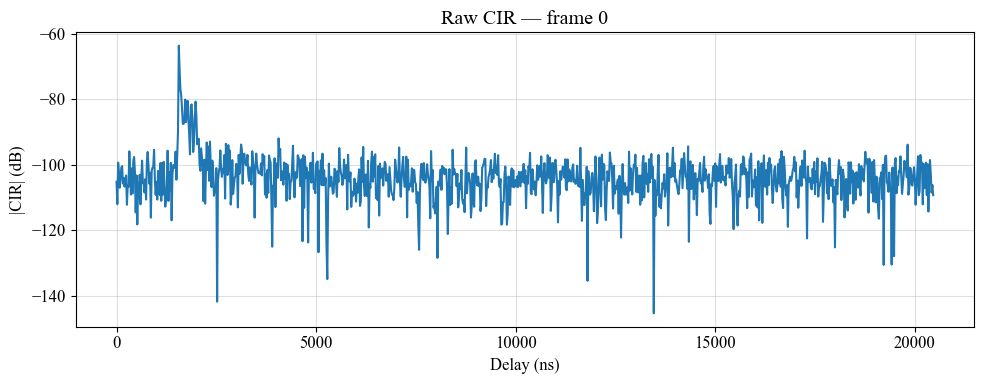

In [10]:
# ── CIR magnitude of a single frame ─────────────────────────────────────────
frame_idx = 0
cir_db = 20 * np.log10(np.abs(cir_raw[frame_idx]) + 1e-10)

plt.figure(figsize=(10, 4))
plt.plot(delay_axis_ns, cir_db)
plt.xlabel('Delay (ns)')
plt.ylabel('|CIR| (dB)')
plt.title(f'Raw CIR — frame {frame_idx}')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

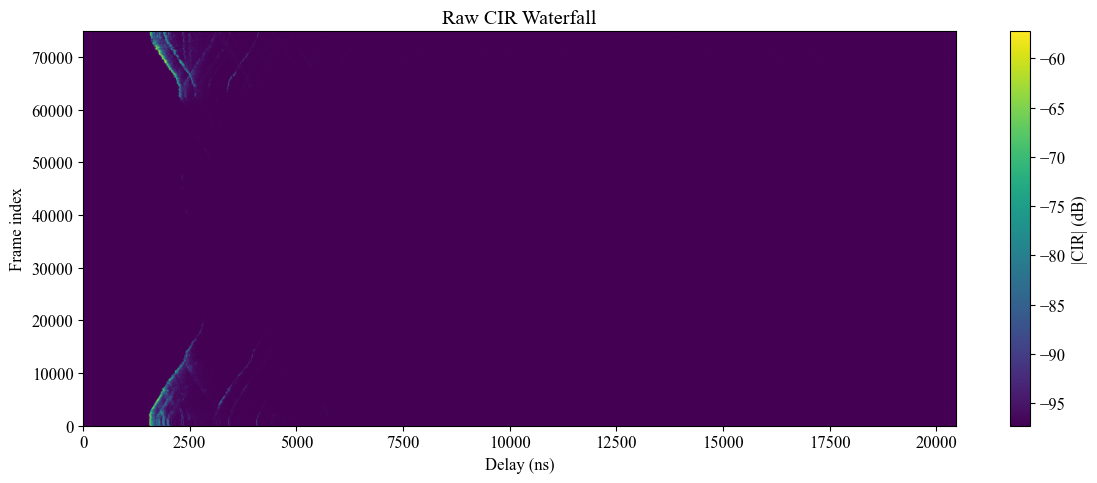

In [11]:
# CIR waterfall (all frames) — GPU
if '_cir_t' not in dir():
    _cir_t = torch.from_numpy(cir_raw).to(_DEVICE)
cir_power_db = (20 * torch.log10(_cir_t.abs() + 1e-10)).cpu().numpy()
vmax = cir_power_db.max()

plt.figure(figsize=(12, 5))
plt.imshow(
    cir_power_db,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    vmin=vmax - 60,
    vmax=vmax,
    extent=[delay_axis_ns[0], delay_axis_ns[-1], 0, n_frames],
)
plt.colorbar(label='|CIR| (dB)')
plt.xlabel('Delay (ns)')
plt.ylabel('Frame index')
plt.title('Raw CIR Waterfall')
plt.xlim([0, 7500])
plt.tight_layout()
plt.show()

## 7  Hardware Configuration

**链路（0513 南航校园测量）**

| 端 | 器件 | 长度 |
|---|---|---|
| TX | A81 电缆 | 7 m |
| RX | A22 电缆 | 0.3 m |
| RX | A81 电缆 | 7 m |

天线：MA802P 全向监测天线（TX/RX 各一根），200~8000 MHz 增益 ≈ 0 dBi。

衰减公式（泰莱微波 A 系列规格书）：$\alpha(f) = K_1\sqrt{f} + K_2 f$ \[dB/100m, $f$ in MHz\]

In [ ]:
import re

# 从文件名自动推断载波频率 (MHz)
_m = re.search(r'(\d{3,4})[Mm]', BIN_PATH.stem)
if _m is None:
    raise ValueError(f'无法从 {BIN_PATH.name} 推断频率，请手动设置 FC_MHZ')
FC_MHZ = float(_m.group(1))

# ── A 系列电缆参数（泰莱微波规格书 K1/K2，dB/100m，f in MHz）─────────────
CABLES = {
    'A81': {'K1': 0.45638,  'K2': 0.000328},
    'A22': {'K1': 1.975832, 'K2': 0.001221},
}
# (cable_name, length_m, side)
CABLE_LINKS = [
    ('A81', 7.0,  'TX'),
    ('A22', 0.3,  'RX'),
    ('A81', 7.0,  'RX'),
]

# ── 天线增益（MA802P，200~8000 MHz ≈ 0 dBi）──────────────────────────────
G_ANT_TX_DBI = 0.0
G_ANT_RX_DBI = 0.0

# ── 功放增益（MiniCircuits ZHL-2W-63-S+，TX 端，规格书实测数据）──────────
# 列：[freq_MHz, gain_dB]，用于插值
_PA_GAIN_TABLE = np.array([
    [ 600, 40.54],
    [1000, 40.13],
    [1500, 41.89],
    [2000, 40.55],
    [2500, 44.65],
    [3000, 42.50],
    [3500, 43.90],
    [4000, 41.57],
    [4500, 42.31],
    [5000, 40.48],
    [5500, 40.76],
    [6000, 40.39],
])

def pa_gain_db_vec(freq_mhz: np.ndarray) -> np.ndarray:
    """插值 ZHL-2W-63-S+ 增益曲线，超出范围取端点值"""
    return np.interp(freq_mhz,
                     _PA_GAIN_TABLE[:, 0],
                     _PA_GAIN_TABLE[:, 1],
                     left=_PA_GAIN_TABLE[0, 1],
                     right=_PA_GAIN_TABLE[-1, 1])

print(f'载波频率 FC = {FC_MHZ:.0f} MHz')
print('电缆配置:')
for name, length_m, side in CABLE_LINKS:
    print(f'  {side}: {name} × {length_m} m')
print(f'天线 MA802P: TX={G_ANT_TX_DBI:.1f} dBi, RX={G_ANT_RX_DBI:.1f} dBi')
print(f'PA ZHL-2W-63-S+ @ {FC_MHZ:.0f} MHz: 增益 = {pa_gain_db_vec(np.array([FC_MHZ]))[0]:.2f} dB')

## 8  Antenna + Cable Calibration（必须）

$$H_{\text{meas}}(f) = H_{\text{cable,TX}}(f) \cdot H_{\text{ant,TX}} \cdot H_{\text{channel}}(f) \cdot H_{\text{ant,RX}} \cdot H_{\text{cable,RX}}(f)$$

天线增益 ≈ 0 dBi，补偿量仅来自电缆。逐频率 bin 计算 RF 频率对应的衰减，
在频域相乘补偿因子：`correction_amp = 10^(loss_dB/20)`。

In [ ]:
def cable_loss_db_vec(freq_mhz: np.ndarray, K1: float, K2: float, length_m: float) -> np.ndarray:
    """A系列电缆衰减向量 [dB]"""
    f = np.abs(freq_mhz)
    return (K1 * np.sqrt(f) + K2 * f) * length_m / 100.0

# 基带频率 → 实际 RF 频率
f_bb_hz  = np.fft.fftfreq(U, d=1.0 / BW_HZ)         # (U,) Hz
f_rf_mhz = (FC_MHZ * 1e6 + f_bb_hz) / 1e6           # (U,) MHz

# 累加所有电缆段损耗
loss_cable_db = np.zeros(U)
for name, length_m, _ in CABLE_LINKS:
    K1, K2 = CABLES[name]['K1'], CABLES[name]['K2']
    loss_cable_db += cable_loss_db_vec(f_rf_mhz, K1, K2, length_m)

# PA 增益（TX 端，增益为正→补偿量减小）
gain_pa_db = pa_gain_db_vec(f_rf_mhz)               # (U,)

# 净补偿：电缆损耗 - 天线增益 - PA 增益
loss_total_db = loss_cable_db - (G_ANT_TX_DBI + G_ANT_RX_DBI) - gain_pa_db

# 幅度补偿因子（可能 < 1，PA 增益大于电缆损耗时）
correction_amp = 10.0 ** (loss_total_db / 20.0)      # (U,)

# 频域校准
CIR_F    = np.fft.fft(cir_raw.astype(np.complex128), axis=1)
cir_cali = np.fft.ifft(CIR_F * correction_amp, axis=1).astype(np.complex64)

# 打印各分量 @ 中心频率
print(f'校准分量 @ FC = {FC_MHZ:.0f} MHz:')
for name, length_m, side in CABLE_LINKS:
    K1, K2 = CABLES[name]['K1'], CABLES[name]['K2']
    l = (K1 * np.sqrt(FC_MHZ) + K2 * FC_MHZ) * length_m / 100.0
    print(f'  + {side} {name}×{length_m}m 损耗: +{l:.3f} dB')
g_pa_fc = pa_gain_db_vec(np.array([FC_MHZ]))[0]
print(f'  - PA ZHL-2W-63-S+ 增益:     -{g_pa_fc:.3f} dB')
print(f'  净校准量: {loss_total_db[0]:.3f} dB  (正=需增强, 负=需衰减)')
print(f'cir_cali.shape = {cir_cali.shape}')

In [ ]:
# ── 校准量频谱（各分量叠加）──────────────────────────────────────────────
f_shift_mhz   = np.fft.fftshift(f_bb_hz) / 1e6
loss_cable_sh = np.fft.fftshift(loss_cable_db)
gain_pa_sh    = np.fft.fftshift(gain_pa_db)
total_sh      = np.fft.fftshift(loss_total_db)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(f_shift_mhz, loss_cable_sh, '--', alpha=0.7, label='Cable loss')
axes[0].plot(f_shift_mhz, gain_pa_sh,    '--', alpha=0.7, label='PA gain (neg.)')
axes[0].plot(f_shift_mhz, total_sh,       lw=2, label='Net correction')
axes[0].axhline(0, color='k', lw=0.8, ls=':')
axes[0].set_xlabel('Baseband Frequency (MHz)')
axes[0].set_ylabel('Correction (dB)')
axes[0].set_title(f'Net Correction @ {FC_MHZ:.0f} MHz  (cable − PA gain)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# 单帧 PDP 对比
frame_idx = 0
delay_axis_ns = np.arange(U) / BW_HZ * 1e9
db_raw  = 20 * np.log10(np.abs(cir_raw [frame_idx]) + 1e-10)
db_cali = 20 * np.log10(np.abs(cir_cali[frame_idx]) + 1e-10)

axes[1].plot(delay_axis_ns, db_raw,  alpha=0.7, label='Raw')
axes[1].plot(delay_axis_ns, db_cali, alpha=0.9, label='Calibrated (cable+PA+ant)')
axes[1].set_xlabel('Delay (ns)')
axes[1].set_ylabel('|CIR| (dB)')
axes[1].set_title(f'Single-Frame CIR — frame {frame_idx}')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ── 校准后 CIR Waterfall ─────────────────────────────────────────────────
import torch
_cir_cali_t = torch.from_numpy(cir_cali).to(_DEVICE)
cir_cali_db = (20 * torch.log10(_cir_cali_t.abs() + 1e-10)).cpu().numpy()
vmax_c = cir_cali_db.max()

_cir_raw_t = torch.from_numpy(cir_raw).to(_DEVICE)
cir_raw_db  = (20 * torch.log10(_cir_raw_t.abs() + 1e-10)).cpu().numpy()
vmax_r = cir_raw_db.max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, vmax, title in zip(
    axes,
    [cir_raw_db,  cir_cali_db],
    [vmax_r,      vmax_c],
    ['Raw CIR Waterfall',
     'Calibrated CIR Waterfall (cable + PA + ant)'],
):
    im = ax.imshow(
        data,
        aspect='auto', origin='lower', cmap='viridis',
        vmin=vmax - 60, vmax=vmax,
        extent=[delay_axis_ns[0], delay_axis_ns[-1], 0, n_frames],
    )
    fig.colorbar(im, ax=ax, label='|CIR| (dB)')
    ax.set_xlabel('Delay (ns)')
    ax.set_ylabel('Frame index')
    ax.set_xlim([0, 7500])
    ax.set_title(title)

plt.suptitle(f'{BIN_PATH.name}  |  FC={FC_MHZ:.0f} MHz', fontsize=11)
plt.tight_layout()
plt.show()

## 9  B2B Calibration（可选）

B2B 数据覆盖 **1400M / 3600M / 4900M**，当前测量数据如有对应频段则可选。

操作步骤：
1. 运行下方 cell，查看候选文件列表
2. 将 `B2B_IDX` 改为对应序号，重新运行
3. 无匹配文件或设为 `None` 则跳过，`cir_final = cir_cali`

In [ ]:
from src.io.b2b_extract import extract_cali_vec

# 查找与当前频段匹配的 B2B 文件
b2b_candidates = sorted(RAW_CALI_DIR.rglob(f'*B2B*{FC_MHZ:.0f}M*.bin'))

print(f'B2B 候选文件 (FC={FC_MHZ:.0f} MHz):')
if b2b_candidates:
    for i, f in enumerate(b2b_candidates):
        print(f'  [{i}] {f.relative_to(RAW_CALI_DIR)}')
else:
    print(f'  ❌ 无 {FC_MHZ:.0f}M B2B 数据，跳过 B2B 校准')

# ── 在此修改选择 ────────────────────────────────────────────────────────────
B2B_IDX = None  # ← 填入序号使用 B2B 校准；None = 跳过

if B2B_IDX is not None and b2b_candidates:
    b2b_path = b2b_candidates[B2B_IDX]
    print(f'\n使用: {b2b_path.name}')

    cali_vec = extract_cali_vec(b2b_path, n_avg=50, mag_avg=True)
    print(f'cali_vec shape={cali_vec.shape}, dtype={cali_vec.dtype}')

    # 频域除以系统响应（加 eps 防零）
    eps = np.abs(cali_vec).max() * 1e-4
    CIR_F_c = np.fft.fft(cir_cali.astype(np.complex128), axis=1)
    cir_final = np.fft.ifft(CIR_F_c / (cali_vec + eps), axis=1).astype(np.complex64)

    # 对比图
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, cir, title in zip(axes,
                               [cir_cali, cir_final],
                               ['After Cable Cali', 'After Cable + B2B Cali']):
        db = 20 * np.log10(np.abs(cir[0]) + 1e-10)
        ax.plot(delay_axis_ns, db)
        ax.set_xlabel('Delay (ns)'); ax.set_ylabel('|CIR| (dB)')
        ax.set_title(title); ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f'✅ B2B 校准完成 → cir_final')
else:
    cir_final = cir_cali
    reason = '无匹配 B2B 文件' if not b2b_candidates else 'B2B_IDX=None'
    print(f'ℹ️  {reason}，cir_final = cir_cali（仅电缆+天线校准）')